# MIOFlow — Hold-One-Out Evaluation on the EB Dataset

**Experiment:** leave-one-out (LOO) trajectory inference accuracy.

For each intermediate timepoint **t**, we:
1. Train MIOFlow on all timepoints **except t** (α-decay / PHATE kernel for GAGA)
2. Predict the cell distribution at **t** by integrating from t−1 → t
3. Evaluate against the held-out ground truth using:
   - **W1** — Wasserstein-1 distance (Earth Mover's Distance with Euclidean ground metric)
   - **MMD-G** — Maximum Mean Discrepancy with Gaussian (RBF) kernel (median-heuristic bandwidth)
   - **MMD-M** — Maximum Mean Discrepancy with mean (linear) kernel = ‖μ_pred − μ_true‖²

Section 5 shows the detailed interpolation plot for the specifically held-out **timepoint 2**.

In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from torchdiffeq import odeint
import ot  # Python Optimal Transport (already a dependency)

from mioflow import MIOFlow, fit_gaga

## 1. Load Data

In [2]:
adata = sc.read_h5ad('data/scRNAseq/preprocessed_eb_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'

In [3]:
time_column = 'time_bin'

sorted_bins = sorted(adata.obs[time_column].unique())
print(f"All time bins: {sorted_bins}")
print(f"Intermediate (LOO candidates): {sorted_bins[1:-1]}")

All time bins: [0.0, 1.0, 2.0, 3.0, 4.0]
Intermediate (LOO candidates): [1.0, 2.0, 3.0]


## 1. Load Data & Visualise

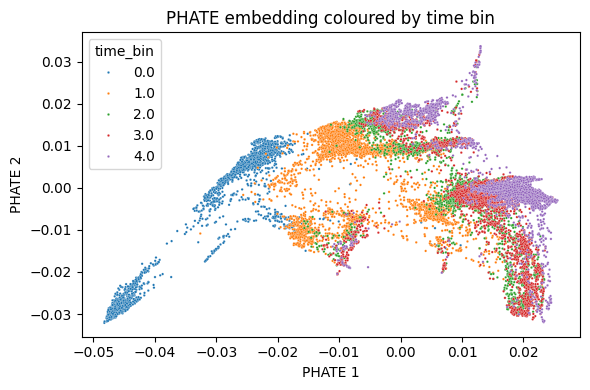

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    x=adata.obsm['X_phate'][:, 0],
    y=adata.obsm['X_phate'][:, 1],
    hue=adata.obs[time_column],
    palette='tab10',
    s=3,
    ax=ax,
)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_title('PHATE embedding coloured by time bin')
plt.tight_layout()
plt.show()

## 2. Train GAGA Autoencoder (on all data)

GAGA is trained **once on the full dataset** — it learns a geometry-preserving latent space
and is shared across all LOO folds.  Only the MIOFlow ODE is retrained per fold.

In [5]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 1024,
    encoder_epochs=300,
    decoder_epochs=300,
    learning_rate=1e-3,
    dist_weight_phase1=1.0,
    recon_weight_phase2=1.0,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 300/300 [01:07<00:00,  4.44it/s, train_loss=0.0063, recon=1.0112, dist=0.0063]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 300/300 [00:42<00:00,  7.01it/s, train_loss=0.7553, recon=0.7553, dist=0.0063]


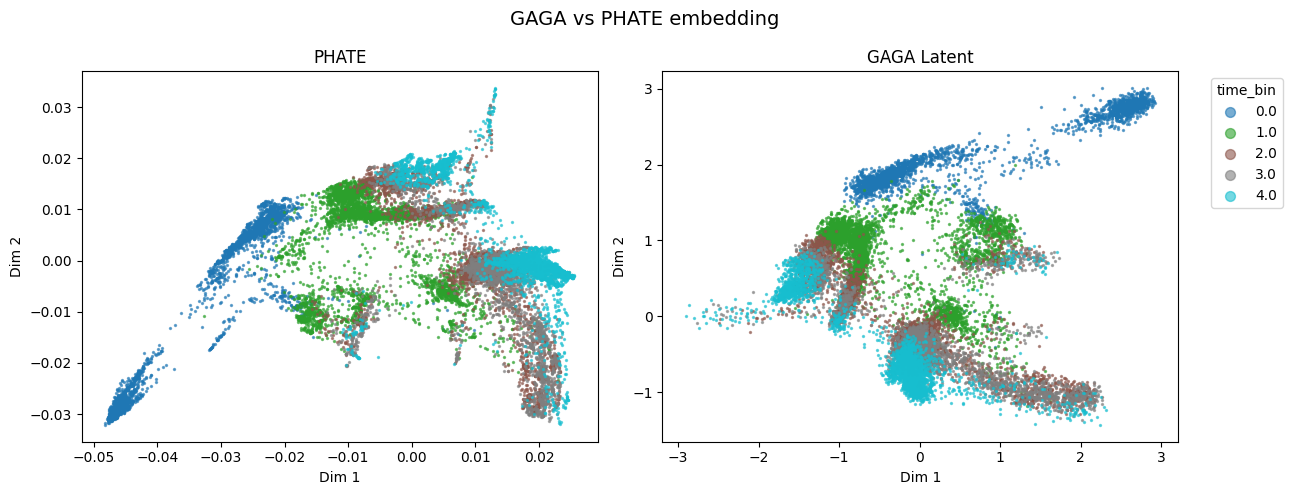

In [6]:
# Encode all cells once with GAGA — used for visualisation and ground-truth evaluation
X_pca_all = adata.obsm['X_pca'].astype('float32')
X_pca_all_scaled = gaga_model.input_scaler.transform(X_pca_all)
gaga_model.eval()
with torch.no_grad():
    gaga_embeddings = gaga_model.encode(torch.tensor(X_pca_all_scaled)).numpy()

adata.obsm['X_gaga'] = gaga_embeddings

# Quick sanity-check plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
categories = adata.obs[time_column].astype('category').cat
codes = categories.codes.values
cat_names = categories.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))

for ax, key, title in zip(axes, ['X_phate', 'X_gaga'], ['PHATE', 'GAGA Latent']):
    for i, name in enumerate(cat_names):
        mask = codes == i
        ax.scatter(adata.obsm[key][mask, 0], adata.obsm[key][mask, 1],
                   color=colors[i], s=2, alpha=0.6, label=name)
    ax.set_title(title); ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

axes[-1].legend(title=time_column, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.suptitle('GAGA vs PHATE embedding', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Helper: train MIOFlow for one LOO fold

Given an `adata_train` (with one timepoint removed), fit MIOFlow and return the trained model.

In [7]:
def train_loo_fold(adata_full, gaga_model, heldout_bin, time_column, n_epochs=300):
    """
    Train MIOFlow on all timepoints except `heldout_bin`.

    Returns the fitted MIOFlow model.
    """
    adata_train = adata_full[adata_full.obs[time_column] != heldout_bin].copy()

    model = MIOFlow(
        adata_train,
        gaga_model=gaga_model,
        obs_time_key=time_column,
        debug_level='warning',   # quiet during LOO loop
        hidden_dim=64,
        use_cuda=torch.cuda.is_available(),
        momentum_beta=0.0,
        scheduler_type='cosine',
        learning_rate=1e-3,
        scheduler_t_max=n_epochs,
        scheduler_min_lr=1e-6,
        n_epochs=n_epochs,
        use_density_loss=True,
        lambda_ot=1.5,
        lambda_density=0.0,
        lambda_energy=0.1,
        energy_time_steps=20,
        sample_size=100,
        n_trajectories=100,
        n_bins=100,
        exp_dir='.',
    )
    model.fit()
    return model

## 4. Helper: predict at a held-out timepoint

After training without `t_held`, we integrate the ODE from the **previous** timepoint to
`t_held` to obtain a predicted point cloud.

**Time-label mapping** (factorisation detail):  
`pd.factorize(sort=True)` re-indexes the training time bins starting from 0.
If the original bins are `[0, 1, 2, 3, 4, …]` and we hold out bin `2`, the training
labels become `[0, 1, 2, 3, …]` where training-label 1 = original bin 1,
training-label 2 = original bin 3.  
Original bin 2 falls at fraction `(2−1)/(3−1) = 0.5` of that interval, so we integrate
to training-label `1.5`.

In [8]:
def predict_at_heldout(mioflow_model, adata_full, gaga_model, heldout_bin, time_column,
                        n_trajectories=None, seed=42):
    """
    Predict the cell distribution at `heldout_bin` using a model trained without it.

    Parameters
    ----------
    n_trajectories : int or None
        If set, subsample this many cells from X_prev as starting points.

    Returns
    -------
    pred_latent  : (n, 2)  — predicted GAGA latent positions (for metrics + visualisation)
    true_latent  : (m, 2)  — ground-truth GAGA latent positions (for metrics + visualisation)
    """
    all_bins = sorted(adata_full.obs[time_column].unique())
    heldout_idx = all_bins.index(heldout_bin)
    t_prev = all_bins[heldout_idx - 1]
    t_next = all_bins[heldout_idx + 1]

    frac = (heldout_bin - t_prev) / (t_next - t_prev)
    training_bins = [b for b in all_bins if b != heldout_bin]
    label_prev = float(training_bins.index(t_prev))
    label_next = float(training_bins.index(t_next))
    t_label_heldout = label_prev + frac * (label_next - label_prev)

    data_idx_prev = training_bins.index(t_prev)
    X_prev_norm = mioflow_model.dataset.time_series_data[data_idx_prev][0]

    if n_trajectories is not None and n_trajectories < len(X_prev_norm):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X_prev_norm), size=n_trajectories, replace=False)
        X_prev_norm = X_prev_norm[idx]

    X_tensor = torch.tensor(X_prev_norm, dtype=torch.float32)
    t_eval = torch.tensor([label_prev, t_label_heldout], dtype=torch.float32)

    mioflow_model.ode_model.eval()
    with torch.no_grad():
        traj = odeint(mioflow_model.ode_model, X_tensor, t_eval)

    pred_norm = traj[1].numpy()
    pred_latent = pred_norm * mioflow_model.std_vals + mioflow_model.mean_vals  # GAGA 2D

    # Ground truth: GAGA latent for held-out cells
    mask_held = adata_full.obs[time_column] == heldout_bin
    X_pca_held = adata_full.obsm['X_pca'][mask_held.values].astype('float32')
    X_pca_held_scaled = gaga_model.input_scaler.transform(X_pca_held)
    gaga_model.eval()
    with torch.no_grad():
        true_latent = gaga_model.encode(torch.tensor(X_pca_held_scaled)).numpy()

    return pred_latent, true_latent

## 5. Evaluation Metrics

Metrics are computed in **raw PCA space** (`adata.obsm['X_pca']`, 50D) so results are
directly comparable to other methods (CFM, SB, TrajectoryNet, etc.).

Predictions are decoded from GAGA latent → scaled PCA → PCA via the GAGA decoder.

| Symbol | Formula | Notes |
|--------|---------|-------|
| **W1** | Earth Mover's Distance (Euclidean ground metric) | Subsampled to 1000 cells |
| **MMD-G** | `E[K(x,x')] + E[K(y,y')] − 2E[K(x,y)]`, K = Gaussian | Median-heuristic bandwidth |
| **MMD-M** | `‖mean(X) − mean(Y)‖₂` | L2 norm of the mean difference (identity-map kernel) |

In [9]:
def wasserstein1(X, Y, n_sample=1000, seed=42):
    """W1 between point clouds X and Y — subsampled to n_sample for efficiency."""
    rng = np.random.default_rng(seed)
    ix = rng.choice(len(X), size=min(n_sample, len(X)), replace=False)
    iy = rng.choice(len(Y), size=min(n_sample, len(Y)), replace=False)
    Xs, Ys = X[ix], Y[iy]
    a = ot.unif(len(Xs))
    b = ot.unif(len(Ys))
    M = ot.dist(Xs, Ys, metric='euclidean')   # Euclidean distance → W1
    return float(ot.emd2(a, b, M))


def _gaussian_kernel(X, Y, sigma):
    diff = X[:, None, :] - Y[None, :, :]        # (n, m, d)
    sq_dists = np.sum(diff ** 2, axis=-1)
    return np.exp(-sq_dists / (2.0 * sigma ** 2))


def mmd_gaussian(X, Y):
    """MMD with Gaussian kernel; bandwidth chosen by median heuristic."""
    XY = np.vstack([X, Y])
    M_all = ot.dist(XY, XY, metric='euclidean')
    sigma = float(np.median(M_all[M_all > 0]))
    if sigma == 0:
        sigma = 1.0
    K_XX = _gaussian_kernel(X, X, sigma)
    K_YY = _gaussian_kernel(Y, Y, sigma)
    K_XY = _gaussian_kernel(X, Y, sigma)
    return float(K_XX.mean() + K_YY.mean() - 2.0 * K_XY.mean())


def mmd_mean(X, Y):
    """L2 norm between sample means (identity-map / linear kernel MMD)."""
    diff = X.mean(axis=0) - Y.mean(axis=0)
    return float(np.linalg.norm(diff))          # ‖μ_X − μ_Y‖₂  (not squared)


def compute_metrics(pred_latent, true_latent):
    return {
        'W1':    wasserstein1(pred_latent, true_latent),
        'MMD_G': mmd_gaussian(pred_latent, true_latent),
        'MMD_M': mmd_mean(pred_latent, true_latent),
    }

print("Metric functions ready.")

Metric functions ready.


## 6. Focal experiment — hold out timepoint 2

Train MIOFlow without timepoint 2, predict at timepoint 2, and visualise the result
in GAGA latent space alongside the ground truth.

In [10]:
FOCAL_BIN = sorted_bins[1]  # timepoint at index 2 in sorted order
print(f"Holding out time bin: {FOCAL_BIN}")

mioflow_focal = train_loo_fold(adata, gaga_model, FOCAL_BIN, time_column)
print(mioflow_focal)

Holding out time bin: 1.0


Training (global): 100%|██████████| 300/300 [00:35<00:00,  8.43it/s]

MIOFlow(n_obs=12661, gaga=Autoencoder, n_epochs=300, trajectories=(100, 100, 2), status=fitted)


### 6.1 Predict and visualise

In [11]:
pred_focal_latent, true_focal_latent = predict_at_heldout(
    mioflow_focal, adata, gaga_model, FOCAL_BIN, time_column, n_trajectories=100,
)
print(f"Predicted  — latent: {pred_focal_latent.shape}")
print(f"Ground truth — latent: {true_focal_latent.shape}")

Predicted  — latent: (100, 2)
Ground truth — latent: (4165, 2)


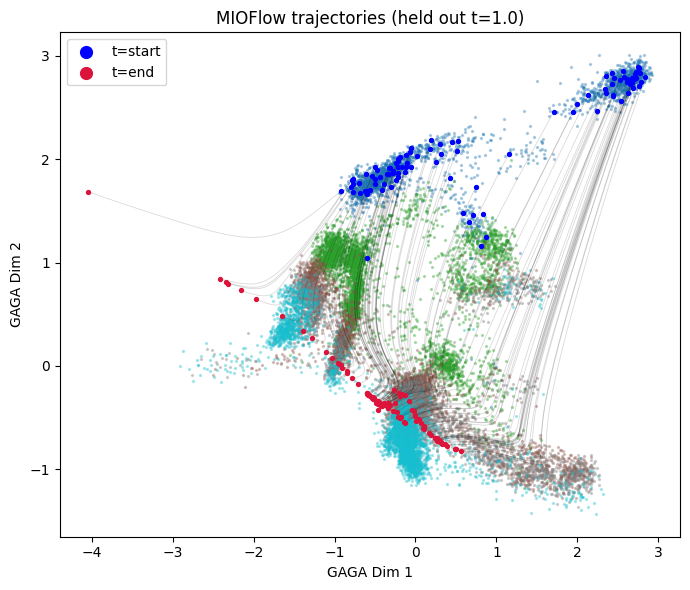

In [12]:
traj = mioflow_focal.trajectories  # (n_bins, n_traj, 2)

fig, ax = plt.subplots(figsize=(7, 6))

# Background: full dataset by timepoint
palette = plt.cm.tab10(np.linspace(0, 1, len(sorted_bins)))
for i, tb in enumerate(sorted_bins):
    mask = adata.obs[time_column] == tb
    ax.scatter(adata.obsm['X_gaga'][mask, 0], adata.obsm['X_gaga'][mask, 1],
               color=palette[i], s=2, alpha=0.3, rasterized=True)

# Draw each trajectory as a line through time bins
for j in range(traj.shape[1]):
    ax.plot(traj[:, j, 0], traj[:, j, 1],
            color='black', alpha=0.15, linewidth=0.6)

# Mark start and end
ax.scatter(traj[0, :, 0],  traj[0, :, 1],  color='blue',   s=8, zorder=5, label='t=start')
ax.scatter(traj[-1, :, 0], traj[-1, :, 1], color='crimson', s=8, zorder=5, label='t=end')

ax.set_title(f'MIOFlow trajectories (held out t={FOCAL_BIN})')
ax.set_xlabel('GAGA Dim 1'); ax.set_ylabel('GAGA Dim 2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


### 6.2 Interpolation plot — predicted vs. ground truth at timepoint 1

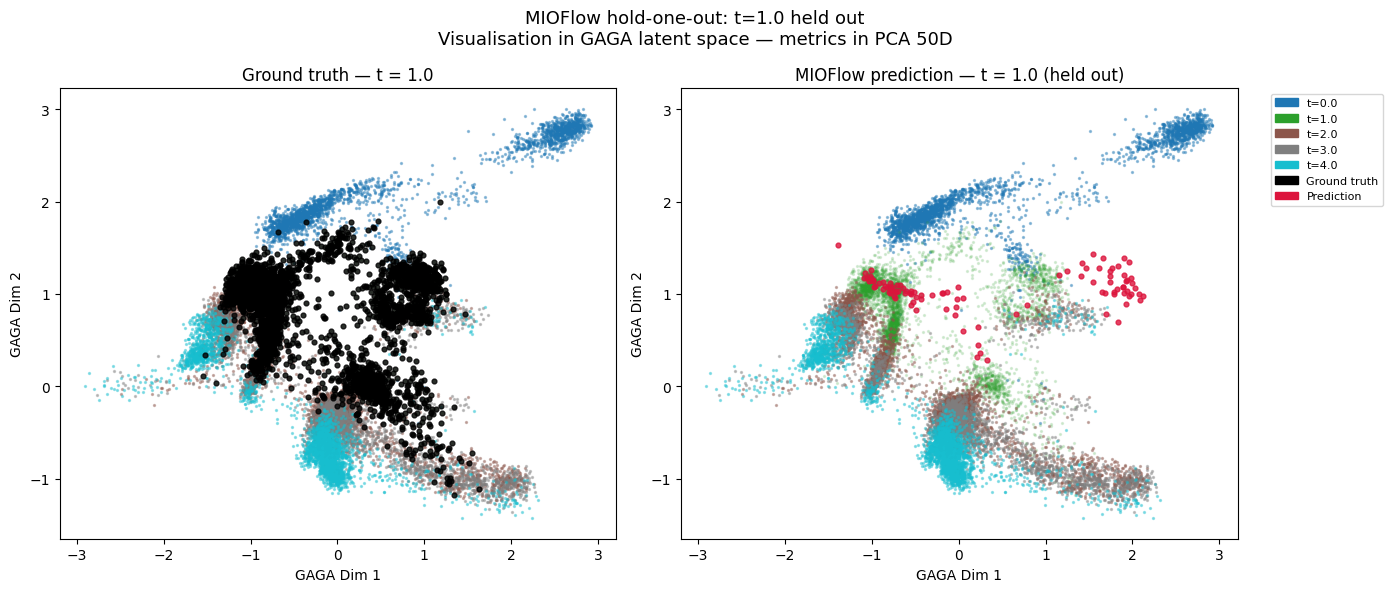

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = plt.cm.tab10(np.linspace(0, 1, len(sorted_bins)))

for ax in axes:
    for i, tb in enumerate(sorted_bins):
        mask = adata.obs[time_column] == tb
        alpha = 0.15 if tb == FOCAL_BIN else 0.4
        ax.scatter(
            adata.obsm['X_gaga'][mask, 0],
            adata.obsm['X_gaga'][mask, 1],
            color=palette[i], s=2, alpha=alpha,
            rasterized=True,
        )

ax = axes[0]
ax.scatter(true_focal_latent[:, 0], true_focal_latent[:, 1],
           color='black', s=12, alpha=0.8, zorder=5)
ax.set_title(f'Ground truth — t = {FOCAL_BIN}')
ax.set_xlabel('GAGA Dim 1'); ax.set_ylabel('GAGA Dim 2')

ax = axes[1]
ax.scatter(pred_focal_latent[:, 0], pred_focal_latent[:, 1],
           color='crimson', s=12, alpha=0.8, zorder=5)
ax.set_title(f'MIOFlow prediction — t = {FOCAL_BIN} (held out)')
ax.set_xlabel('GAGA Dim 1'); ax.set_ylabel('GAGA Dim 2')

handles = [mpatches.Patch(color=palette[i], label=f't={tb}') for i, tb in enumerate(sorted_bins)]
handles += [
    mpatches.Patch(color='black',  label='Ground truth'),
    mpatches.Patch(color='crimson', label='Prediction'),
]
axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.suptitle(
    f'MIOFlow hold-one-out: t={FOCAL_BIN} held out\n'
    'Visualisation in GAGA latent space — metrics in PCA 50D',
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 6.3 Metrics for held-out timepoint 2

In [14]:
metrics_focal = compute_metrics(pred_focal_latent, true_focal_latent)
df_focal = pd.DataFrame([{'Held-out t': FOCAL_BIN, **metrics_focal}])
print(df_focal.to_string(index=False))
df_focal

 Held-out t       W1    MMD_G   MMD_M
        1.0 0.807199 0.139617 0.76995


,Held-out t,W1,MMD_G,MMD_M
0,1.0,0.807199,0.139617,0.76995


## 7. Full Leave-One-Out Table

Loop over every intermediate timepoint (all except first and last), train a separate
MIOFlow fold, and record W1, MMD-G, MMD-M.

> **Note:** this cell trains one model per intermediate timepoint (~5 min each on CPU).

In [15]:
N_TRAJ = 100 # fixed seed population for comparability across methods

loo_results = []

for heldout_bin in sorted_bins[1:-1]:
    print(f"\n{'='*50}")
    print(f"  LOO fold: holding out timepoint {heldout_bin}")
    print(f"{'='*50}")

    if heldout_bin == FOCAL_BIN:
        pred_latent, true_latent = pred_focal_latent, true_focal_latent
    else:
        mioflow_loo = train_loo_fold(adata, gaga_model, heldout_bin, time_column)
        pred_latent, true_latent = predict_at_heldout(
            mioflow_loo, adata, gaga_model, heldout_bin, time_column,
            n_trajectories=N_TRAJ,
        )

    metrics = compute_metrics(pred_latent, true_latent)   # metrics in GAGA 2D space
    loo_results.append({'t': heldout_bin, **metrics})
    print(f"  W1={metrics['W1']:.4f}  MMD-G={metrics['MMD_G']:.4f}  MMD-M={metrics['MMD_M']:.4f}")

df_loo = pd.DataFrame(loo_results)
print("\nDone.")
df_loo


  LOO fold: holding out timepoint 1.0
  W1=0.8072  MMD-G=0.1396  MMD-M=0.7700

  LOO fold: holding out timepoint 2.0


Training (global): 100%|██████████| 300/300 [00:36<00:00,  8.13it/s]


  W1=0.4689  MMD-G=0.0255  MMD-M=0.1973

  LOO fold: holding out timepoint 3.0


Training (global): 100%|██████████| 300/300 [00:38<00:00,  7.84it/s]


  W1=0.4101  MMD-G=0.0209  MMD-M=0.3646

Done.


,t,W1,MMD_G,MMD_M
0,1.0,0.807199,0.139617,0.769950
1,2.0,0.468946,0.025478,0.197320
2,3.0,0.410137,0.020889,0.364576


### 7.1 Summary table — LOO W1 and MMD (MIOFlow, α-decay kernel)

In [16]:
# Pretty-print the table with 4 decimal places
df_display = df_loo.copy()
df_display.columns = ['Held-out t', 'W1', 'MMD (G)', 'MMD (M)']
df_display = df_display.set_index('Held-out t')

# Add mean row
df_display.loc['Mean'] = df_display.mean()

styled = df_display.style \
    .format('{:.4f}') \
    .set_caption('Leave-one-out W1 and MMD — MIOFlow (EB dataset, α-decay kernel)') \
    .highlight_min(color='#d4efdf', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :]) \
    .highlight_max(color='#fadbd8', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :])

styled

,W1,MMD (G),MMD (M)
Held-out t,,,
1.000000,0.8072,0.1396,0.7700
2.000000,0.4689,0.0255,0.1973
3.000000,0.4101,0.0209,0.3646
Mean,0.5621,0.0620,0.4439


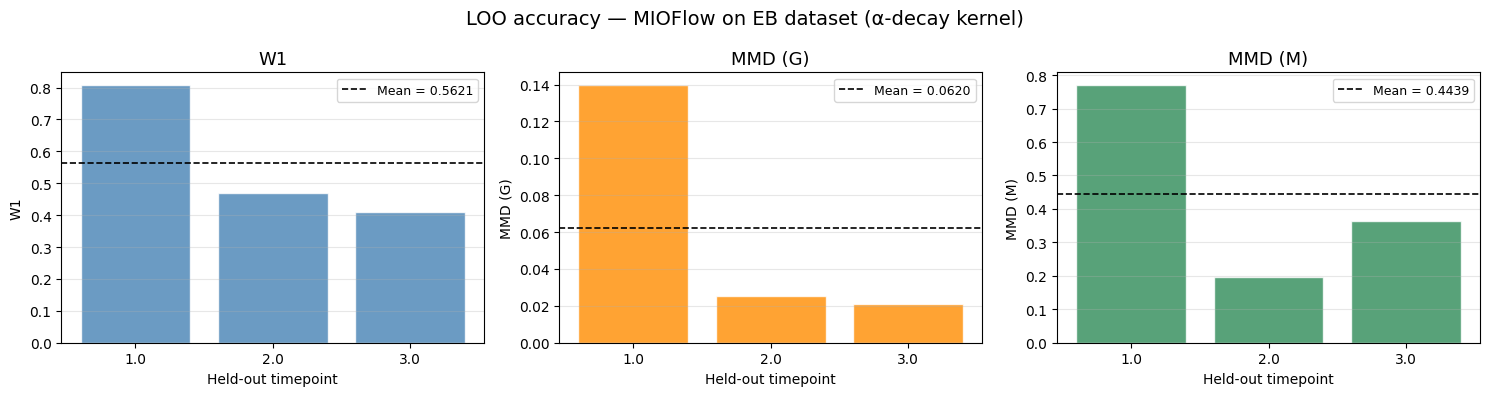

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

metrics_cols = ['W1', 'MMD_G', 'MMD_M']
labels       = ['W1', 'MMD (G)', 'MMD (M)']
colors       = ['steelblue', 'darkorange', 'seagreen']

for ax, col, label, color in zip(axes, metrics_cols, labels, colors):
    vals = df_loo[col].values
    ts   = df_loo['t'].astype(str).values
    ax.bar(ts, vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean = {vals.mean():.4f}')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Held-out timepoint')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('LOO accuracy — MIOFlow on EB dataset (α-decay kernel)', fontsize=14)
plt.tight_layout()
plt.show()